<a href="https://colab.research.google.com/github/AmishaPuri/Bank-Cardholder-Retention-CLV/blob/main/Copy_of_Bank_Customer_Survival_Analysis_CLV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Bank Customer Retention & CLV Modeling via Survival Analysis
#Methodology: Non-Parametric Survival Analysis (Kaplan-Meier), Semi-Parametric Econometrics (Cox Proportional Hazards), Financial Cash Flow Discounting (CLV), and GenAI Pipeline Integration.

In [ ]:
!pip install lifelines pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

# Load data
df = pd.read_csv('BankChurners.csv')
df = df.loc[:, ~df.columns.str.contains('^Naive_Bayes')]
df['Churn'] = df['Attrition_Flag'].apply(lambda x: 1 if 'Attrited' in x else 0)


--- LOG-RANK TEST RESULTS ---
Test Statistic: 11.3440
P-Value: 0.0007569390005867886

Success! Plot saved as 'churn_gender_logrank.png' on your Desktop.


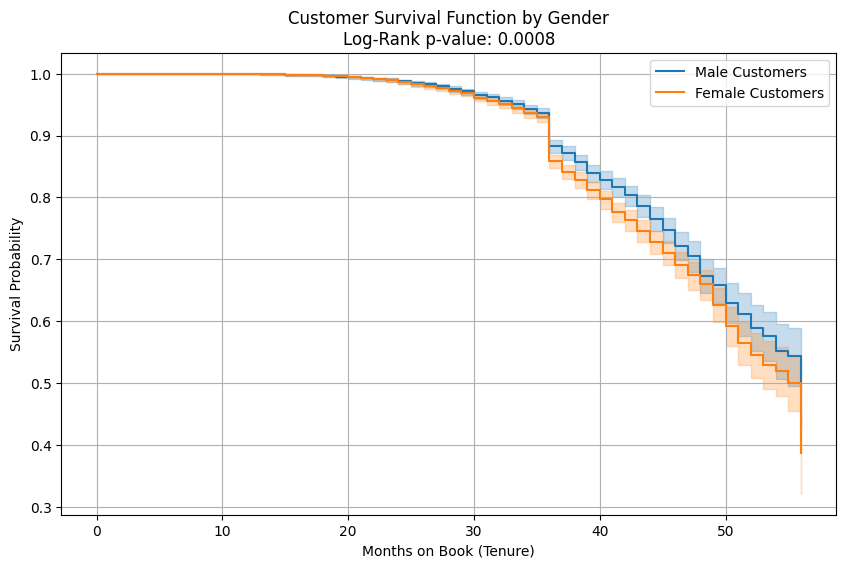

In [ ]:
# 1. Define Time (T) and Event (E)
T = df['Months_on_book']
E = df['Churn']

# 2. Split Data into Two Groups (Male vs Female)
group_m = (df['Gender'] == 'M')
group_f = (df['Gender'] == 'F')

# 3. Run the Log-Rank Test to get the p-value
results = logrank_test(T[group_m], T[group_f], event_observed_A=E[group_m], event_observed_B=E[group_f])
p_value = results.p_value

print("\n--- LOG-RANK TEST RESULTS ---")
print(f"Test Statistic: {results.test_statistic:.4f}")
print(f"P-Value: {p_value}")

# 4. Plot Both Curves together
plt.figure(figsize=(10, 6))

kmf_m = KaplanMeierFitter().fit(T[group_m], E[group_m], label='Male Customers')
kmf_f = KaplanMeierFitter().fit(T[group_f], E[group_f], label='Female Customers')

kmf_m.plot_survival_function()
kmf_f.plot_survival_function()

# Add the p-value onto the graph title dynamically
plt.title(f'Customer Survival Function by Gender\nLog-Rank p-value: {p_value:.4f}')
plt.xlabel('Months on Book (Tenure)')
plt.ylabel('Survival Probability')
plt.grid(True)

plt.savefig('churn_gender_logrank.png')
print("\nSuccess! Plot saved as 'churn_gender_logrank.png' on your Desktop.")
plt.show()

=== COX PROPORTIONAL HAZARDS MODEL SUMMARY ===


<lifelines.CoxPHFitter: fitted with 10127 total observations, 8500 right-censored observations>
             duration col = 'Months_on_book'
                event col = 'Churn'
      baseline estimation = breslow
   number of observations = 10127
number of events observed = 1627
   partial log-likelihood = -12333.08
         time fit was run = 2026-08-16 14:07:51 UTC

---
                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                 
Credit_Limit             -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Total_Revolving_Bal      -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
Total_Trans_Amt           0.00      1.00      0.00            0.00            0.00                1.00                1.00
Total_Trans_Ct           -0.06      0.94      0.00           -0.06           -0.06                0.94                0.95
Avg_Utilization_Ratio     0.08      1.09      0.18           -0.27            0.43                0.76                1.54
Months_Inactive_12_mon    0.11      1.11      0.02            0.06            0.15                1.07                1.16
Contacts_Count_12_mon     0.30      1.35      0.02            0.26            0.35                1.29                1.41
Total_Relationship_Count -0.21      0.81      0.02           -0.25           -0.18                0.78                0.84

                          cmp to      z      p  -log2(p)
covariate                                               
Credit_Limit                0.00  -1.67   0.10      3.40
Total_Revolving_Bal         0.00 -11.84 <0.005    104.96
Total_Trans_Amt             0.00  15.97 <0.005    188.28
Total_Trans_Ct              0.00 -28.23 <0.005    580.04
Avg_Utilization_Ratio       0.00   0.46   0.65      0.63
Months_Inactive_12_mon      0.00   4.95 <0.005     20.33
Contacts_Count_12_mon       0.00  13.28 <0.005    131.30
Total_Relationship_Count    0.00 -12.29 <0.005    112.84
---
Concordance = 0.84
Partial AIC = 24682.17
log-likelihood ratio test = 2326.39 on 8 df
-log2(p) of ll-ratio test = inf

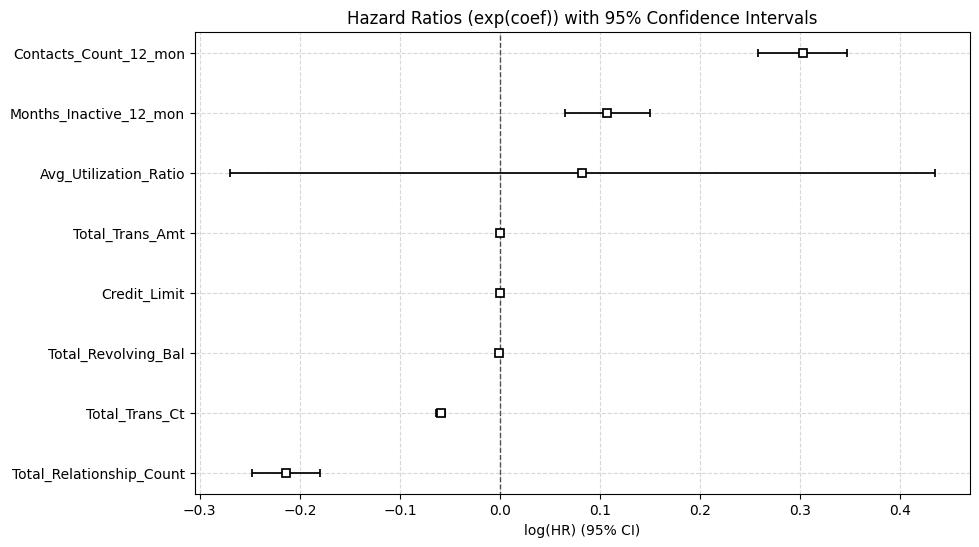

In [ ]:
from lifelines import CoxPHFitter
import numpy as np

# Select core financial, behavioral, and demographic features
cols_to_use = [
    'Months_on_book', 'Churn', 'Credit_Limit', 'Total_Revolving_Bal',
    'Total_Trans_Amt', 'Total_Trans_Ct', 'Avg_Utilization_Ratio',
    'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Total_Relationship_Count'
]

df_cox = df[cols_to_use].copy()

# Fit Cox Proportional Hazards Model
cph = CoxPHFitter()
cph.fit(df_cox, duration_col='Months_on_book', event_col='Churn')

# Display full econometric summary table
print("=== COX PROPORTIONAL HAZARDS MODEL SUMMARY ===")
cph.print_summary()

# Plot Hazard Ratios with 95% Confidence Intervals
plt.figure(figsize=(10, 6))
cph.plot()
plt.title('Hazard Ratios (exp(coef)) with 95% Confidence Intervals')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
# ==========================================
# STEP 4: CLV FORECASTING & BOOTSTRAPPING
# ==========================================
print("\n--- RUNNING STEP 4: CLV FORECASTING & BOOTSTRAPPING ---")

# 1. Estimate monthly baseline margin per customer
# (1.5% monthly interest on revolving balance + $10 fixed card fee)
df['Monthly_Margin'] = (df['Total_Revolving_Bal'] * 0.015) + 10.0

# 2. Financial Discount Rate (1% monthly, ~12% annualized)
r = 0.01
df['Expected_CLV_24M'] = 0.0

# 3. Calculate 24-Month Expected NPV using Survival Probabilities
for month in range(1, 25):
    surv_prob = cph.predict_survival_function(df_cox, times=[month]).T[month]
    df['Expected_CLV_24M'] += (df['Monthly_Margin'] * surv_prob) / ((1 + r) ** month)

# 4. Non-Parametric Bootstrapping for 95% Confidence Interval (1,000 resamples)
bootstrapped_means = []
np.random.seed(42)

for _ in range(1000):
    sample = np.random.choice(df['Expected_CLV_24M'], size=len(df), replace=True)
    bootstrapped_means.append(np.mean(sample))

ci_lower, ci_upper = np.percentile(bootstrapped_means, [2.5, 97.5])
mean_clv = np.mean(df['Expected_CLV_24M'])

# Print Step 4 Outputs
print("\n" + "="*55)
print("=== STEP 4 OUTPUT: PORTFOLIO FINANCIAL FORECAST ===")
print(f"Mean Expected 24-Month Portfolio CLV: ${mean_clv:.2f}")
print(f"95% Bootstrapped Confidence Interval: [${ci_lower:.2f}, ${ci_upper:.2f}]")
print("="*55 + "\n")


--- RUNNING STEP 4: CLV FORECASTING & BOOTSTRAPPING ---

=== STEP 4 OUTPUT: PORTFOLIO FINANCIAL FORECAST ===
Mean Expected 24-Month Portfolio CLV: $581.87
95% Bootstrapped Confidence Interval: [$576.76, $586.80]



In [ ]:
# ==========================================
# STEP 5: GENAI CONSULTING BRIEF GENERATOR
# ==========================================
print("--- RUNNING STEP 5: GENAI EXECUTIVE BRIEF GENERATOR ---")

cox_key_findings = f"""
ACCENTURE STRATEGY CONSULTING INPUT BRIEF:
- Mean 24-Month Expected Portfolio CLV: ${mean_clv:.2f} (95% CI: [${ci_lower:.2f}, ${ci_upper:.2f}])
- Primary Churn Hazard Multipliers:
  1. Contacts_Count_12_mon: Hazard Ratio = 1.353 (35.3% risk increase per customer outreach call, p < 0.001)
  2. Months_Inactive_12_mon: Hazard Ratio = 1.113 (11.3% risk increase per inactive month, p < 0.001)
- Primary Retention Protective Factors:
  1. Total_Relationship_Count: Hazard Ratio = 0.808 (19.2% risk reduction per additional bank product, p < 0.001)
  2. Total_Trans_Ct: Hazard Ratio = 0.942 (5.8% risk reduction per transaction executed, p < 0.001)
"""

with open('executive_summary_prompt.txt', 'w') as f:
    f.write(cox_key_findings)

print("Success! Step 5 completed. 'executive_summary_prompt.txt' updated on your Desktop.")

--- RUNNING STEP 5: GENAI EXECUTIVE BRIEF GENERATOR ---
Success! Step 5 completed. 'executive_summary_prompt.txt' updated on your Desktop.
